In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive/')
    %cd /content/drive/My Drive/Colab Notebooks/WignerCamp2026
except:
    IN_COLAB = False
    %load_ext autoreload
    %autoreload 2
print(f'Running on {"Google colab" if IN_COLAB else "Local computer"}')

Running on Local computer


In [2]:
import os
from typing import Dict

import torch
import torch.nn.functional as F
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
def load_image(path: str) -> torch.Tensor:
    """
    Load an image and convert it to a PyTorch tensor.

    Parameters
    ----------
    path : str
        Path to the input image.

    Returns
    -------
    torch.Tensor
        Tensor of shape (1, C, H, W) with values in [0, 1].
    """
    image = Image.open(path).convert("RGB")
    transform = transforms.ToTensor()
    tensor = transform(image).unsqueeze(0)  # (1, C, H, W)
    return tensor


def save_image(tensor: torch.Tensor, path: str) -> None:
    """
    Save a PyTorch tensor as an image.

    Parameters
    ----------
    tensor : torch.Tensor
        Tensor of shape (1, C, H, W).
    path : str
        Output file path.
    """
    tensor = tensor.squeeze(0).clamp(0, 1)
    transform = transforms.ToPILImage()
    image = transform(tensor)
    image.save(path)
def apply_kernel(image: torch.Tensor, kernel: torch.Tensor) -> torch.Tensor:
    """
    Apply a convolution kernel to an RGB image.

    Parameters
    ----------
    image : torch.Tensor
        Input image tensor of shape (1, C, H, W).
    kernel : torch.Tensor
        Kernel tensor of shape (1, 1, kH, kW).

    Returns
    -------
    torch.Tensor
        Output image tensor of shape (1, C, H, W).
    """
    C = image.shape[1]

    # Apply same kernel independently to each channel
    kernel = kernel.repeat(C, 1, 1, 1)

    padding = kernel.shape[-1] // 2

    output = F.conv2d(image, kernel, padding=padding, groups=C)

    return output


In [18]:
def tensor_to_image(t: torch.Tensor) -> np.ndarray:
    """
    Convert tensor (1, C, H, W) → numpy (H, W, C).
    """
    t = t.squeeze(0).detach().cpu()
    return t.permute(1, 2, 0).numpy()
def normalize(img: torch.Tensor) -> torch.Tensor:
    """
    Normalize tensor for visualization.

    Parameters
    ----------
    img : torch.Tensor

    Returns
    -------
    torch.Tensor
    """
    min_val = img.min()
    max_val = img.max()
    if max_val > min_val:
        img = (img - min_val) / (max_val - min_val)
    return img
def plot_convolution_diagram(
    image: torch.Tensor,
    kernel: torch.Tensor,
    result: torch.Tensor,
    title: str = ""
) -> None:
    """
    Plot [image] * [kernel] = [result] with improved layout.
    """

    plt.rcParams.update({
        "font.size": 18,
        "text.usetex": True,
        "font.family": "serif",
    })

    img_np = tensor_to_image(image)
    res_np = tensor_to_image(normalize(result))

    kernel_np = kernel.squeeze().detach().cpu().numpy()

    fig = plt.figure(figsize=(6, 3))

    # Wider table, narrow symbols
    gs = fig.add_gridspec(
        1, 5,
        width_ratios=[3, 0.15, 4, 0.15, 3]
    )

    # --- Original image ---
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(img_np)
    ax0.axis("off")

    # --- Star ---
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.text(0.5, 0.5, r"$\ast$", ha="center", va="center")
    ax1.axis("off")

    # --- Kernel table ---
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.axis("off")

    table = ax2.table(
        cellText=np.round(kernel_np, 2),
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(16)

    # Make cells wider and taller
    table.scale(2.2, 2.8)
    table.auto_set_column_width(col=list(range(kernel_np.shape[1])))

    # Increase internal padding
    for cell in table.get_celld().values():
        cell.PAD = 0.2

    # --- Equals ---
    ax3 = fig.add_subplot(gs[0, 3])
    ax3.text(0.5, 0.5, r"$=$", ha="center", va="center")
    ax3.axis("off")

    # --- Result image ---
    ax4 = fig.add_subplot(gs[0, 4])
    ax4.imshow(res_np)
    ax4.axis("off")

    # Title (reduced padding)
    if title:
        fig.suptitle(title, fontsize=18, y=0.8)

    plt.tight_layout(rect=[0, 0, 1, 0.85])
    #plt.show()

In [19]:
input_path = "../img/chair.jpg"
output_dir = "../img/generated"

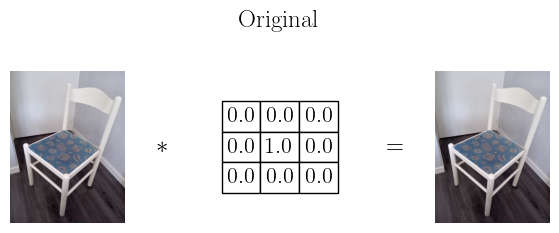

In [20]:
# Identity
image = load_image(input_path)
title = "Original"
kernel = torch.tensor([
        [0, 0, 0],
        [0, 1, 0],
        [0, 0, 0]
    ], dtype=torch.float32)

output = apply_kernel(image, kernel)
plot_convolution_diagram(image, kernel, output, "Original")
plt.savefig(f"{output_dir}/original.jpg")